# Step 6 — Trigger logic and the four-cell table

Spec: `CLAUDE.md` §6 step 6. Step 5 was skipped (decision of 2026-09-16): there is no field-level
loss data, so the Step 1c optical reference supplies flooded / not flooded directly.

**This table measures flood detection performance, not loss prediction.** `truth` is whether the
Step 1c reference places the field in standing water on 15 March. Hits and misses are detections and
failures to detect, never losses paid or missed.

- **Rain trigger:** event total > T for T in 50, 75, 100 mm, per product (4 products × 3 thresholds).
- **Image trigger:** Sentinel-1 flooded fraction > 0.3 **or** (ΔNDVI < −0.15 with ≥ 2 clear post
  observations).
- **Dual trigger:** rain **and** image.
- **truth:** flooded = at least 30% of the field inside the 15 March extent; not flooded = 5% or
  less **and** at least half the field clear that day; everything else is unknown and excluded from
  the tables but counted.

Output: `data/derived/units.csv`, every per-unit value used, including the flagged sequence B and C
fields.

**CHECKPOINT:** the four-cell tables. This is the core result.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import common as C

FLOODED_MIN, DRY_MAX, CLEAR_MIN = 0.3, 0.05, 0.5
S1_TRIGGER, NDVI_TRIGGER, MIN_CLEAR_OBS = 0.3, -0.15, 2
THRESHOLDS = [50, 75, 100]
PRODUCTS = list(C.RAIN)


def read(name, **kw):
    df = pd.read_csv(C.DERIVED / name, **kw)
    for col in ("unit_id", "field_id"):
        if col in df.columns:
            df[col] = df[col].astype(str)
    return df


units_all = read("01_units_dwr.csv")
s1 = read("02_units_s1_flood.csv")[["unit_id", "s1_vv", "s1_vh", "s1_both"]]
ndvi = read("03_units_ndvi.csv")[["unit_id", "pre_ndvi", "post_ndvi", "d_ndvi", "pre_n", "post_n"]]
back = read("02b_field_backscatter.csv")
back = back.loc[back.crop_class == "T20", ["field_id", "opt15", "clear15", "pre_vv", "post_vv",
                                           "d_vv", "base_vv", "base_vh"]].rename(
    columns={"field_id": "unit_id"})
conf = read("02c_units_confound.csv")
conf = conf[[c for c in ("field_id", "elev_m", "km_to_river", "d_vv_31") if c in conf.columns]]
conf = conf.rename(columns={"field_id": "unit_id"})
rain = read("04_units_rainfall.csv")
rain_cols = ["unit_id"] + [f"{p}_{w}" for p in PRODUCTS for w in ("event", "jan")]

u = (units_all.merge(s1, on="unit_id", how="left")
     .merge(ndvi, on="unit_id", how="left")
     .merge(back, on="unit_id", how="left")
     .merge(conf, on="unit_id", how="left")
     .merge(rain[rain_cols], on="unit_id", how="left"))
u["truth"] = np.where(u.opt15 >= FLOODED_MIN, "flooded",
                      np.where((u.opt15 <= DRY_MAX) & (u.clear15 >= CLEAR_MIN), "not_flooded",
                               "unknown"))
u.loc[~u.is_unit.astype(bool), "truth"] = "not a unit (sequence B/C)"
u["rain_spread_mm"] = u[[f"{p}_event" for p in PRODUCTS]].max(axis=1) - \
                      u[[f"{p}_event" for p in PRODUCTS]].min(axis=1)
u["image_trigger"] = ((u.s1_vv > S1_TRIGGER)
                      | ((u.d_ndvi < NDVI_TRIGGER) & (u.post_n >= MIN_CLEAR_OBS)))

units = u[u.is_unit.astype(bool)]
print(f"n units = {len(units)} | truth: {units.truth.value_counts().to_dict()}")
print(f"sequence B/C fields carried in the table with no imagery values: "
      f"{int((~u.is_unit.astype(bool)).sum())}")
print(f"image trigger fires on {int(units.image_trigger.sum())} units "
      f"(S1 > {S1_TRIGGER}: {int((units.s1_vv > S1_TRIGGER).sum())}; "
      f"ΔNDVI < {NDVI_TRIGGER}: {int(((units.d_ndvi < NDVI_TRIGGER) & (units.post_n >= MIN_CLEAR_OBS)).sum())})")
print(f"datasets: {C.UNITS_ASSET}, {C.S1}, {C.S2}, " + ", ".join(v[0] for v in C.RAIN.values()))

n units = 1320 | truth: {'not_flooded': 719, 'unknown': 583, 'flooded': 18}
sequence B/C fields carried in the table with no imagery values: 615
image trigger fires on 21 units (S1 > 0.3: 11; ΔNDVI < -0.15: 12)
datasets: projects/cropczyk/assets/strawberry_fields_dwr_wy2023, COPERNICUS/S1_GRD, COPERNICUS/S2_SR_HARMONIZED, NOAA/CPC/Precipitation, OREGONSTATE/PRISM/ANd, NASA/ORNL/DAYMET_V4, NASA/GPM_L3/IMERG_V07


## The per-unit table (deliverable `data/derived/units.csv`)

In [2]:
COLS = ["unit_id", "is_unit", "sequence", "COUNTY", "ACRES", "lon", "lat", "elev_m", "km_to_river",
        "t20_peak_date", "crop_sequence", "truth", "opt15", "clear15",
        "s1_vv", "s1_vh", "s1_both", "pre_vv", "post_vv", "d_vv", "d_vv_31", "base_vv", "base_vh",
        "pre_ndvi", "post_ndvi", "d_ndvi", "pre_n", "post_n", "image_trigger",
        *[f"{p}_event" for p in PRODUCTS], *[f"{p}_jan" for p in PRODUCTS], "rain_spread_mm"]
out = u[[c for c in COLS if c in u.columns]]
OUTFILE = C.DERIVED / "units.csv"
out.to_csv(OUTFILE, index=False)
print(f"Wrote {OUTFILE.name}: {len(out)} rows ({int(out.is_unit.astype(bool).sum())} units, "
      f"{int((~out.is_unit.astype(bool)).sum())} flagged sequence B/C fields), {len(out.columns)} columns")
print("columns:", ", ".join(out.columns))
print(f"n units = {int(out.is_unit.astype(bool).sum())} | date windows: S1 pre 2023-02-01 to "
      f"2023-03-08, post 2023-03-19; NDVI post 2023-03-20 to 2023-04-30; rain 2023-03-09 to "
      f"2023-03-14; optical 2023-03-15 | datasets: {C.UNITS_ASSET}, {C.S1}, {C.S2}, "
      + ", ".join(v[0] for v in C.RAIN.values()))

Wrote units.csv: 1935 rows (1320 units, 615 flagged sequence B/C fields), 38 columns
columns: unit_id, is_unit, sequence, COUNTY, ACRES, lon, lat, elev_m, km_to_river, t20_peak_date, crop_sequence, truth, opt15, clear15, s1_vv, s1_vh, s1_both, pre_vv, post_vv, d_vv, d_vv_31, base_vv, base_vh, pre_ndvi, post_ndvi, d_ndvi, pre_n, post_n, image_trigger, cpc_event, prism_event, daymet_event, imerg_event, cpc_jan, prism_jan, daymet_jan, imerg_jan, rain_spread_mm
n units = 1320 | date windows: S1 pre 2023-02-01 to 2023-03-08, post 2023-03-19; NDVI post 2023-03-20 to 2023-04-30; rain 2023-03-09 to 2023-03-14; optical 2023-03-15 | datasets: projects/cropczyk/assets/strawberry_fields_dwr_wy2023, COPERNICUS/S1_GRD, COPERNICUS/S2_SR_HARMONIZED, NOAA/CPC/Precipitation, OREGONSTATE/PRISM/ANd, NASA/ORNL/DAYMET_V4, NASA/GPM_L3/IMERG_V07


## Four-cell tables: rain-only against dual

hit = trigger fires on a flooded field; miss = no trigger on a flooded field; false alarm = trigger
fires on a field the reference shows dry; correct reject = no trigger on a dry field. Detection
rate = hits / flooded; false-alarm rate = false alarms / not flooded.

In [3]:
ev = units[units.truth.isin(["flooded", "not_flooded"])].copy()
flooded, dry = ev.truth == "flooded", ev.truth == "not_flooded"
print(f"units in the tables: {int(flooded.sum())} flooded, {int(dry.sum())} not flooded "
      f"({int((units.truth == 'unknown').sum())} unknown, excluded)")


def four_cell(fires, label, product, thr):
    return {"design": label, "product": product, "threshold (mm)": thr,
            "hit": int((fires & flooded).sum()), "miss": int((~fires & flooded).sum()),
            "false alarm": int((fires & dry).sum()), "correct reject": int((~fires & dry).sum()),
            "detection rate": (fires & flooded).sum() / max(flooded.sum(), 1),
            "false-alarm rate": (fires & dry).sum() / max(dry.sum(), 1),
            "units paid": int(fires.sum())}


rows = []
for p in PRODUCTS:
    for t in THRESHOLDS:
        rain_fires = ev[f"{p}_event"] > t
        rows.append(four_cell(rain_fires, "rain only", p, t))
        rows.append(four_cell(rain_fires & ev.image_trigger, "dual (rain and image)", p, t))
rows.append(four_cell(ev.image_trigger, "image only", "-", np.nan))
cells_df = pd.DataFrame(rows)

for label in ["rain only", "dual (rain and image)"]:
    d = cells_df[cells_df.design == label]
    print(f"\n{label.upper()}")
    print(d[["product", "threshold (mm)", "hit", "miss", "false alarm", "correct reject",
             "detection rate", "false-alarm rate", "units paid"]].to_string(
        index=False, formatters={"detection rate": "{:.0%}".format,
                                 "false-alarm rate": "{:.0%}".format}))
d = cells_df[cells_df.design == "image only"]
print("\nIMAGE ONLY (no rain condition)")
print(d[["hit", "miss", "false alarm", "correct reject", "detection rate", "false-alarm rate",
         "units paid"]].to_string(index=False, formatters={"detection rate": "{:.0%}".format,
                                                           "false-alarm rate": "{:.0%}".format}))
cells_df.to_csv(C.DERIVED / "06_four_cell_tables.csv", index=False)
print("\nWrote 06_four_cell_tables.csv")
print(f"n units = {len(units)} | date windows: rain 2023-03-09 to 2023-03-14; S1 post 2023-03-19; "
      f"NDVI post 2023-03-20 to 2023-04-30 | datasets: " + ", ".join(v[0] for v in C.RAIN.values())
      + f", {C.S1}, {C.S2}")

units in the tables: 18 flooded, 719 not flooded (583 unknown, excluded)

RAIN ONLY
product  threshold (mm)  hit  miss  false alarm  correct reject detection rate false-alarm rate  units paid
    cpc            50.0   18     0          719               0           100%             100%         737
    cpc            75.0   18     0          715               4           100%              99%         733
    cpc           100.0    0    18            2             717             0%               0%           2
  prism            50.0   18     0          719               0           100%             100%         737
  prism            75.0   15     3          327             392            83%              45%         342
  prism           100.0    1    17           93             626             6%              13%          94
 daymet            50.0   18     0          719               0           100%             100%         737
 daymet            75.0   15     3          265     

## What the tables say

In [4]:
rain_only = cells_df[cells_df.design == "rain only"]
dual = cells_df[cells_df.design == "dual (rain and image)"]
img = cells_df[cells_df.design == "image only"].iloc[0]

best_rain = rain_only.loc[(rain_only["detection rate"] - rain_only["false-alarm rate"]).idxmax()]
best_dual = dual.loc[(dual["detection rate"] - dual["false-alarm rate"]).idxmax()]
print("READING")
print(f"  Rain only, best of 12 combinations: {best_rain['product']} at "
      f"{int(best_rain['threshold (mm)'])} mm, detection {best_rain['detection rate']:.0%}, "
      f"false alarm {best_rain['false-alarm rate']:.0%}, paying {best_rain['units paid']} units.")
print(f"  Dual, best of 12: {best_dual['product']} at {int(best_dual['threshold (mm)'])} mm, "
      f"detection {best_dual['detection rate']:.0%}, false alarm {best_dual['false-alarm rate']:.0%}, "
      f"paying {best_dual['units paid']} units.")
print(f"  Image only: detection {img['detection rate']:.0%}, false alarm "
      f"{img['false-alarm rate']:.0%}, paying {img['units paid']} units.")
print()
print("  The image gate caps the dual design: adding it to any rain trigger cannot raise detection")
print(f"  above the {img['detection rate']:.0%} the image gate achieves on its own, and on these")
print("  units it removes far more true detections than false alarms.")
worst = rain_only[rain_only["false-alarm rate"] > 0.9]
if len(worst):
    print(f"  {len(worst)} of the 12 rain-only combinations have a false-alarm rate above 90%: at")
    print("  those thresholds the trigger pays nearly every dry field in the study area.")
print()
print("  None of this measures loss. It measures whether a trigger fires where the optical")
print("  reference saw standing water on 15 March.")
print(f"n units = {len(units)} | datasets: " + ", ".join(v[0] for v in C.RAIN.values())
      + f", {C.S1}, {C.S2}")

READING
  Rain only, best of 12 combinations: daymet at 100 mm, detection 83%, false alarm 20%, paying 162 units.
  Dual, best of 12: cpc at 50 mm, detection 33%, false alarm 1%, paying 15 units.
  Image only: detection 33%, false alarm 1%, paying 15 units.

  The image gate caps the dual design: adding it to any rain trigger cannot raise detection
  above the 33% the image gate achieves on its own, and on these
  units it removes far more true detections than false alarms.
  5 of the 12 rain-only combinations have a false-alarm rate above 90%: at
  those thresholds the trigger pays nearly every dry field in the study area.

  None of this measures loss. It measures whether a trigger fires where the optical
  reference saw standing water on 15 March.
n units = 1320 | datasets: NOAA/CPC/Precipitation, OREGONSTATE/PRISM/ANd, NASA/ORNL/DAYMET_V4, NASA/GPM_L3/IMERG_V07, COPERNICUS/S1_GRD, COPERNICUS/S2_SR_HARMONIZED


## Sensitivity: does the gate do better on a larger flooded set?

The four-cell tables call a unit flooded at **30% or more** of the field inside the 15 March
extent, which gives 18 units and 270 acres — about 14% of the 1,919 acres the county reported
lost. A reviewer will ask whether the gate looks better on a more inclusive definition that
covers more of the county figure. Relaxing the threshold to any detected water gives 54 units
and 1,123 acres, 58% of the county figure. (Two further units sit between 0 and 0.01%
inundation — a pixel's worth — and are excluded as noise.)

In [5]:
RULES = [(0.30, ">= 30% inundated (spec default)"),
         (0.10, ">= 10% inundated"),
         (1e-4, "any detected water (>= 0.01%)")]
rows = []
for thr, label in RULES:
    sel = units[units.opt15 >= thr]
    radar = sel.s1_vv > S1_TRIGGER
    ndvi = (sel.d_ndvi < NDVI_TRIGGER) & (sel.post_n >= MIN_CLEAR_OBS)
    either = radar | ndvi
    rows.append({"inclusion rule": label, "units": len(sel), "acres": sel.ACRES.sum(),
                 "% of 1,919 ac": 100 * sel.ACRES.sum() / 1919,
                 "radar fires": int(radar.sum()), "NDVI fires": int(ndvi.sum()),
                 "either": int(either.sum()),
                 "detection rate": either.mean()})
sens = pd.DataFrame(rows)
print("Gate detection against three inclusion rules for 'flooded':")
print(sens.to_string(index=False, formatters={
    "acres": "{:,.0f}".format, "% of 1,919 ac": "{:.1f}%".format,
    "detection rate": "{:.0%}".format}))
print()

wide = units[units.opt15 >= 1e-4]
fell, rose = wide.d_vv < 0, wide.d_vv >= 0
print(f"On the 54-unit set, VV fell on {int(fell.sum())} units and rose on {int(rose.sum())}.")
print(f"  The radar gate fired on {int((wide.s1_vv > S1_TRIGGER)[fell].sum())} of "
      f"{int(fell.sum())} where VV fell, and "
      f"{int((wide.s1_vv > S1_TRIGGER)[rose].sum())} of {int(rose.sum())} where it rose.")
print()
print("READING")
print("  Widening the flooded set does NOT improve the gate; it makes it worse. Detection")
print(f"  falls from {sens.iloc[0]['detection rate']:.0%} on the 18-unit reference set to "
      f"{sens.iloc[-1]['detection rate']:.0%} on the 54-unit set, because the units added by")
print("  relaxing the threshold are the partly flooded ones, and the gate catches almost none")
print("  of them. The absolute count barely moves (6 to 9 of a set three times the size).")
print("  The mechanism is unchanged and visible again here: the radar gate fires essentially")
print("  only where backscatter fell, and on mulched beds it rose.")
print("  This strengthens the §9 conclusion rather than qualifying it: the gate's 33% detection")
print("  on the reference set is its best case, not a threshold artefact.")
sens.to_csv(C.DERIVED / "06_inclusion_sensitivity.csv", index=False)
print("\nWrote 06_inclusion_sensitivity.csv")
print(f"n units = {len(units)} | date windows: S1 post 2023-03-19; NDVI post 2023-03-20 to "
      f"2023-04-30; optical 2023-03-15 | datasets: {C.S1}, {C.S2}, {C.UNITS_ASSET}")

Gate detection against three inclusion rules for 'flooded':
                 inclusion rule  units acres % of 1,919 ac  radar fires  NDVI fires  either detection rate
>= 30% inundated (spec default)     18   270         14.1%            3           3       6            33%
               >= 10% inundated     30   564         29.4%            6           4       9            30%
  any detected water (>= 0.01%)     54 1,123         58.5%            6           4       9            17%

On the 54-unit set, VV fell on 7 units and rose on 47.
  The radar gate fired on 6 of 7 where VV fell, and 0 of 47 where it rose.

READING
  Widening the flooded set does NOT improve the gate; it makes it worse. Detection
  falls from 33% on the 18-unit reference set to 17% on the 54-unit set, because the units added by
  relaxing the threshold are the partly flooded ones, and the gate catches almost none
  of them. The absolute count barely moves (6 to 9 of a set three times the size).
  The mechanism is 

## Figure 5 — four-cell results, rain-only against dual

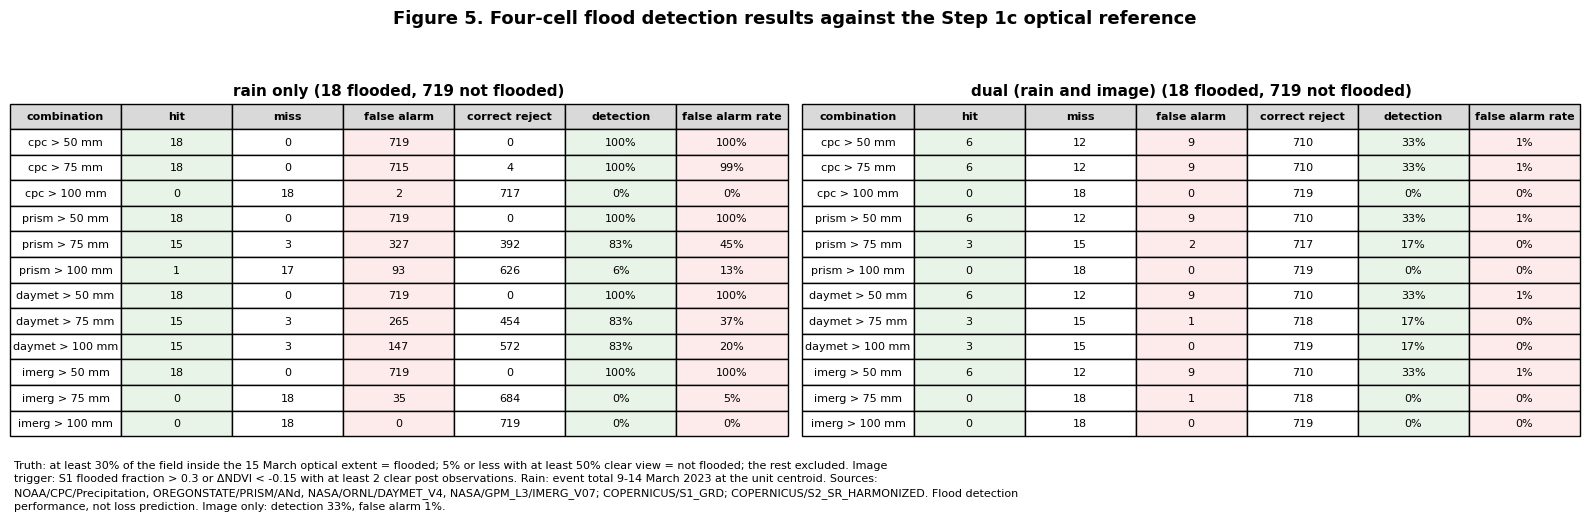

Saved fig5_four_cell_results.png
n units = 1320 | datasets: NOAA/CPC/Precipitation, OREGONSTATE/PRISM/ANd, NASA/ORNL/DAYMET_V4, NASA/GPM_L3/IMERG_V07, COPERNICUS/S1_GRD, COPERNICUS/S2_SR_HARMONIZED


In [6]:
import textwrap

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))
for ax, label in zip(axes, ["rain only", "dual (rain and image)"]):
    d = cells_df[cells_df.design == label].copy()
    # note: d.product is pandas DataFrame.product, so use bracket access for the column
    d["combination"] = d["product"] + " > " + d["threshold (mm)"].astype(int).astype(str) + " mm"
    tbl = d[["combination", "hit", "miss", "false alarm", "correct reject"]].copy()
    tbl["detection"] = d["detection rate"].map("{:.0%}".format).values
    tbl["false alarm rate"] = d["false-alarm rate"].map("{:.0%}".format).values
    ax.axis("off")
    t = ax.table(cellText=tbl.values, colLabels=tbl.columns, cellLoc="center",
                 bbox=[0, 0, 1, 1])
    t.auto_set_font_size(False)
    t.set_fontsize(8)
    for (r, c), cell in t.get_celld().items():
        if r == 0:
            cell.set_facecolor("0.85")
            cell.set_text_props(fontweight="bold")
        elif c in (1, 5):
            cell.set_facecolor("#e8f4e8")
        elif c in (3, 6):
            cell.set_facecolor("#fdeaea")
    ax.set_title(f"{label} (18 flooded, {int((ev.truth == 'not_flooded').sum())} not flooded)",
                 fontsize=11, fontweight="bold")

fig.suptitle("Figure 5. Four-cell flood detection results against the Step 1c optical reference",
             fontsize=13, fontweight="bold")
footer = (f"Truth: at least {FLOODED_MIN:.0%} of the field inside the 15 March optical extent = flooded; "
          f"{DRY_MAX:.0%} or less with at least {CLEAR_MIN:.0%} clear view = not flooded; the rest excluded. "
          f"Image trigger: S1 flooded fraction > {S1_TRIGGER} or ΔNDVI < {NDVI_TRIGGER} with at least "
          f"{MIN_CLEAR_OBS} clear post observations.\n"
          f"Rain: event total 9-14 March 2023 at the unit centroid. Sources: "
          + ", ".join(v[0] for v in C.RAIN.values()) + f"; {C.S1}; {C.S2}. "
          f"Flood detection performance, not loss prediction. Image only: detection "
          f"{img['detection rate']:.0%}, false alarm {img['false-alarm rate']:.0%}.")
fig.text(0.012, 0.015, textwrap.fill(footer, 165), fontsize=8, va="bottom", linespacing=1.4)
fig.tight_layout(rect=(0, 0.13, 1, 0.93))
FIG = C.FIGURES / "fig5_four_cell_results.png"
fig.savefig(FIG, dpi=200)
plt.show()
print(f"Saved {FIG.name}")
print(f"n units = {len(units)} | datasets: " + ", ".join(v[0] for v in C.RAIN.values())
      + f", {C.S1}, {C.S2}")